# DBSCAN — An Illustrated Tour

> A cluster is a **dense region** separated from other dense regions by sparse space. DBSCAN walks from one core point to its $\varepsilon$-neighbours and lets shapes emerge.

---

**What we cover:**
- The three point types — core, border, noise
- The two knobs — $\varepsilon$ and `min_samples`
- The k-distance plot — picking $\varepsilon$ from the data
- DBSCAN vs K-Means on non-convex data
- Failure mode — varying density

## The picture — density: core, border, noise points

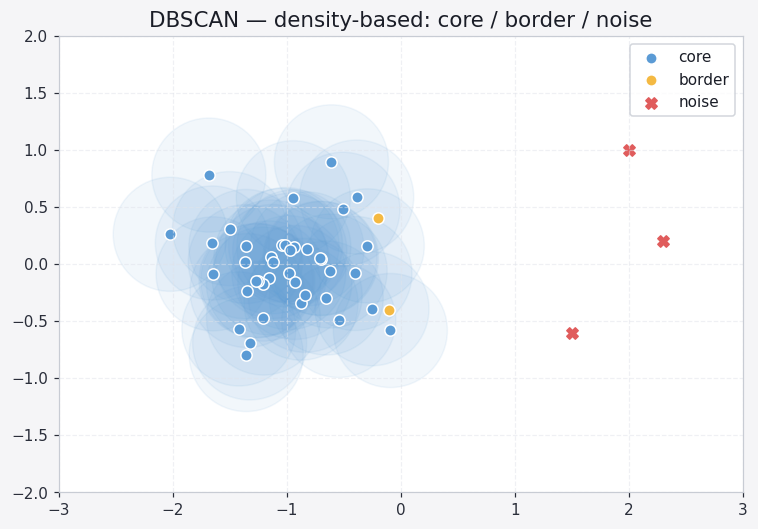

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
core   = rng.randn(40, 2)*0.4 + np.array([-1, 0])
border = np.array([[-0.2, 0.4], [-0.1, -0.4]])
noise  = np.array([[2.0, 1.0], [1.5, -0.6], [2.3, 0.2]])
fig, ax = plt.subplots(figsize=(7, 5))
for p in core:
    ax.add_patch(Circle(p, 0.5, color=P[0], alpha=0.08))
ax.scatter(core[:,0], core[:,1],   s=55, color=P[0], edgecolor='white', label='core')
ax.scatter(border[:,0], border[:,1], s=55, color=P[2], edgecolor='white', label='border')
ax.scatter(noise[:,0], noise[:,1],   s=55, color=P[1], marker='X', label='noise')
ax.set_aspect('equal'); ax.set_xlim(-3,3); ax.set_ylim(-2,2)
ax.set_title('DBSCAN — density-based: core / border / noise')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons, make_blobs
from sklearn.neighbors import NearestNeighbors

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'
PALETTE = [C0, C1, CB, CM, CH, CP]

X, _ = make_moons(n_samples=200, noise=0.06, random_state=0)
print('Data:', X.shape)

Data: (200, 2)


---
## Three Point Types

Pick a radius $\varepsilon$ and a count `min_samples`. For every point $x$ count its neighbours inside the $\varepsilon$-ball:

- **Core point** — at least `min_samples` neighbours within $\varepsilon$. Lives in the dense interior.
- **Border point** — fewer than `min_samples` neighbours, but is a neighbour *of* a core point. Sits on the rim.
- **Noise point** — neither core nor border. Tagged as cluster $-1$.

A cluster is the transitive closure of "core-reaches-core". DBSCAN does not need a $k$ in advance and produces clusters of arbitrary shape.

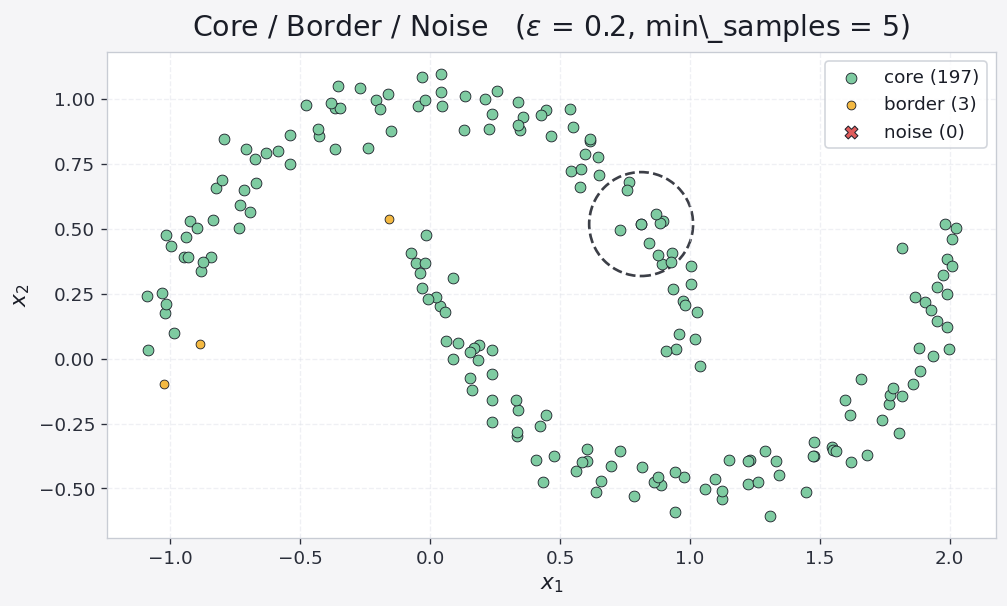

In [3]:
eps, min_samples = 0.20, 5
db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
labels = db.labels_
core_mask = np.zeros(len(X), dtype=bool)
core_mask[db.core_sample_indices_] = True
noise_mask = labels == -1
border_mask = (~core_mask) & (~noise_mask)

fig, ax = plt.subplots(figsize=(8.5, 7))
ax.scatter(X[core_mask,0], X[core_mask,1], c=CM, s=42, edgecolors='#1a1d27', lw=0.5, label=f'core ({core_mask.sum()})', zorder=4)
ax.scatter(X[border_mask,0], X[border_mask,1], c=CB, s=28, edgecolors='#1a1d27', lw=0.5, label=f'border ({border_mask.sum()})', zorder=3)
ax.scatter(X[noise_mask,0], X[noise_mask,1], c=C1, s=60, marker='X', edgecolors='#1a1d27', lw=0.6, label=f'noise ({noise_mask.sum()})', zorder=5)
# Highlight one core's eps-ball
centre = X[db.core_sample_indices_[0]]
circ = plt.Circle(centre, eps, fill=False, color='#1a1d27', lw=1.6, ls='--', alpha=0.85)
ax.add_patch(circ)
ax.set_title(fr'Core / Border / Noise   ($\varepsilon$ = {eps}, min\_samples = {min_samples})', pad=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.legend(loc='upper right'); ax.grid(True); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

---
## Picking $\varepsilon$ — The k-Distance Plot

A common heuristic: plot the sorted distance from each point to its $k$-th nearest neighbour (with $k$ = `min_samples`). The plot rises slowly across normal points and then **kinks upward** where points start being far from neighbours. Set $\varepsilon$ at the kink.

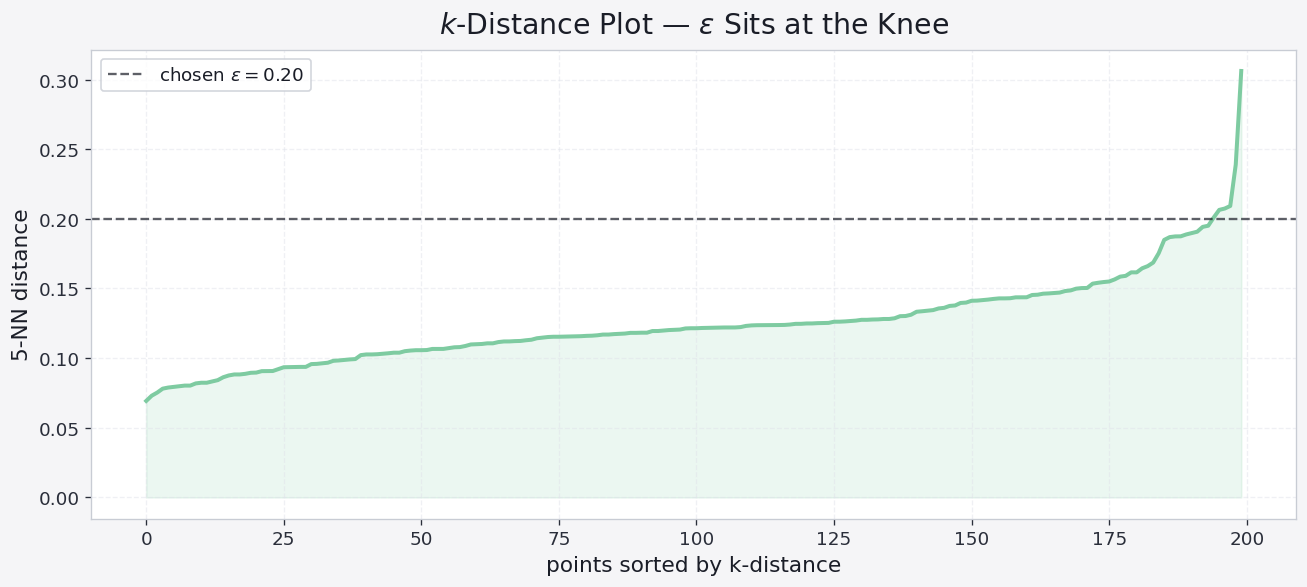

In [4]:
k = 5
nn = NearestNeighbors(n_neighbors=k+1).fit(X)
d, _ = nn.kneighbors(X)
k_dist = np.sort(d[:, k])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(k_dist, color=CM, lw=2.4)
ax.axhline(0.20, color='#1a1d27', ls='--', lw=1.4, alpha=0.7, label=r'chosen $\varepsilon = 0.20$')
ax.fill_between(np.arange(len(k_dist)), 0, k_dist, color=CM, alpha=0.15)
ax.set_xlabel('points sorted by k-distance')
ax.set_ylabel(f'{k}-NN distance')
ax.set_title(r'$k$-Distance Plot — $\varepsilon$ Sits at the Knee', pad=10)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## DBSCAN vs K-Means on Non-Convex Data

K-Means slices a moon in half because its decision regions are convex. DBSCAN walks **along the manifold**, so each crescent stays whole.

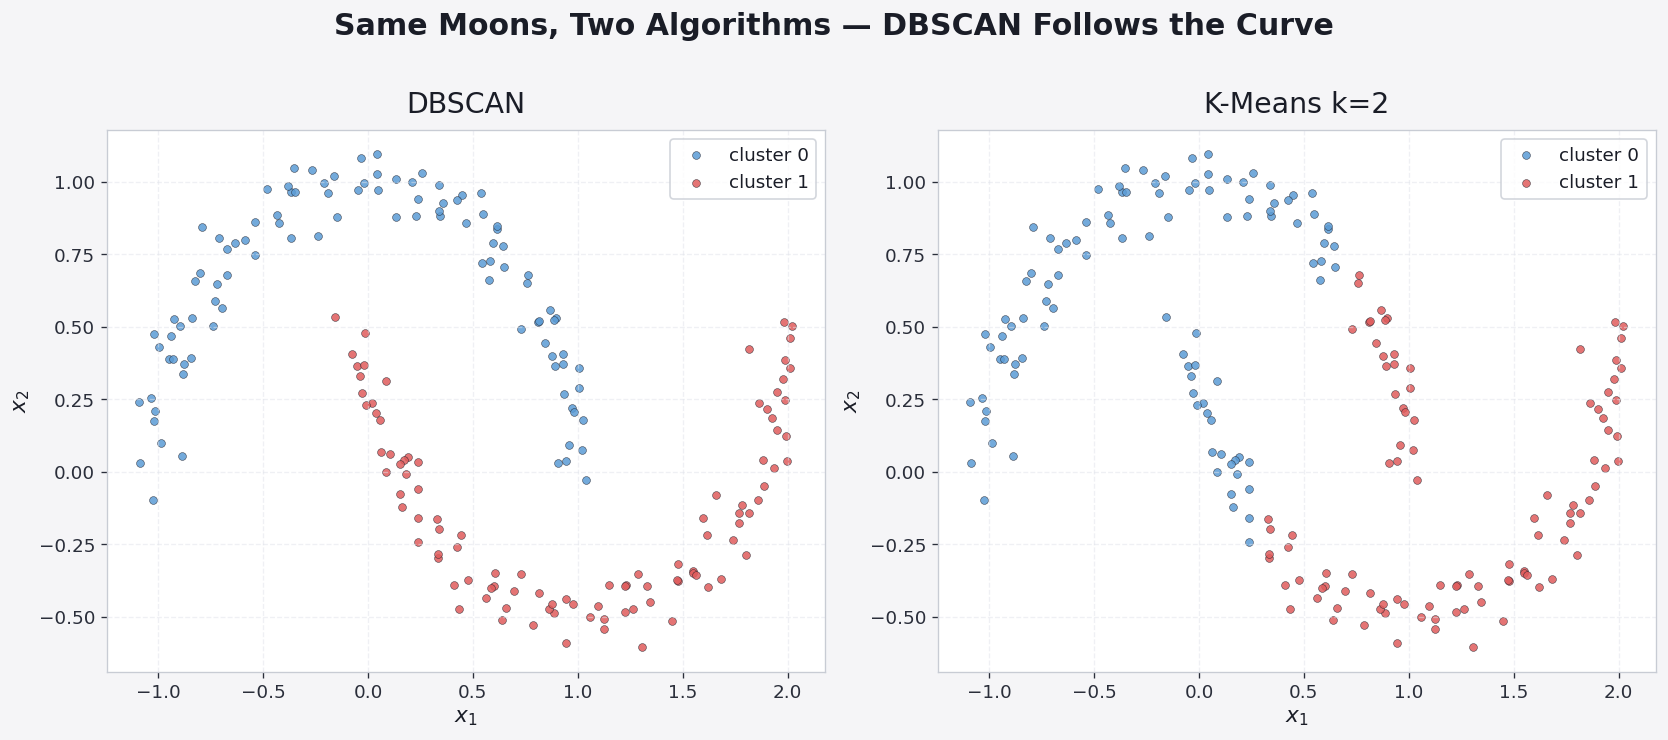

In [5]:
lbl_db = DBSCAN(eps=0.2, min_samples=5).fit_predict(X)
lbl_km = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, lbl) in zip(axes, [('DBSCAN', lbl_db), ('K-Means k=2', lbl_km)]):
    uniq = sorted(set(lbl))
    for j, u in enumerate(uniq):
        m = lbl == u
        if u == -1:
            ax.scatter(X[m,0], X[m,1], c=C1, s=55, marker='X', edgecolors='#1a1d27', lw=0.6, label='noise')
        else:
            ax.scatter(X[m,0], X[m,1], c=PALETTE[j%len(PALETTE)], s=22, edgecolors='#1a1d27', lw=0.3, alpha=0.85, label=f'cluster {u}')
    ax.set_title(name, pad=10); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.legend(); ax.grid(True)
fig.suptitle('Same Moons, Two Algorithms — DBSCAN Follows the Curve', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Failure Mode — Varying Density

DBSCAN uses a **single global $\varepsilon$**. If one cluster is dense and another is sparse, no $\varepsilon$ works for both: too small breaks the sparse one into noise; too large merges the dense one into its neighbour. (HDBSCAN solves this by varying $\varepsilon$ per cluster.)

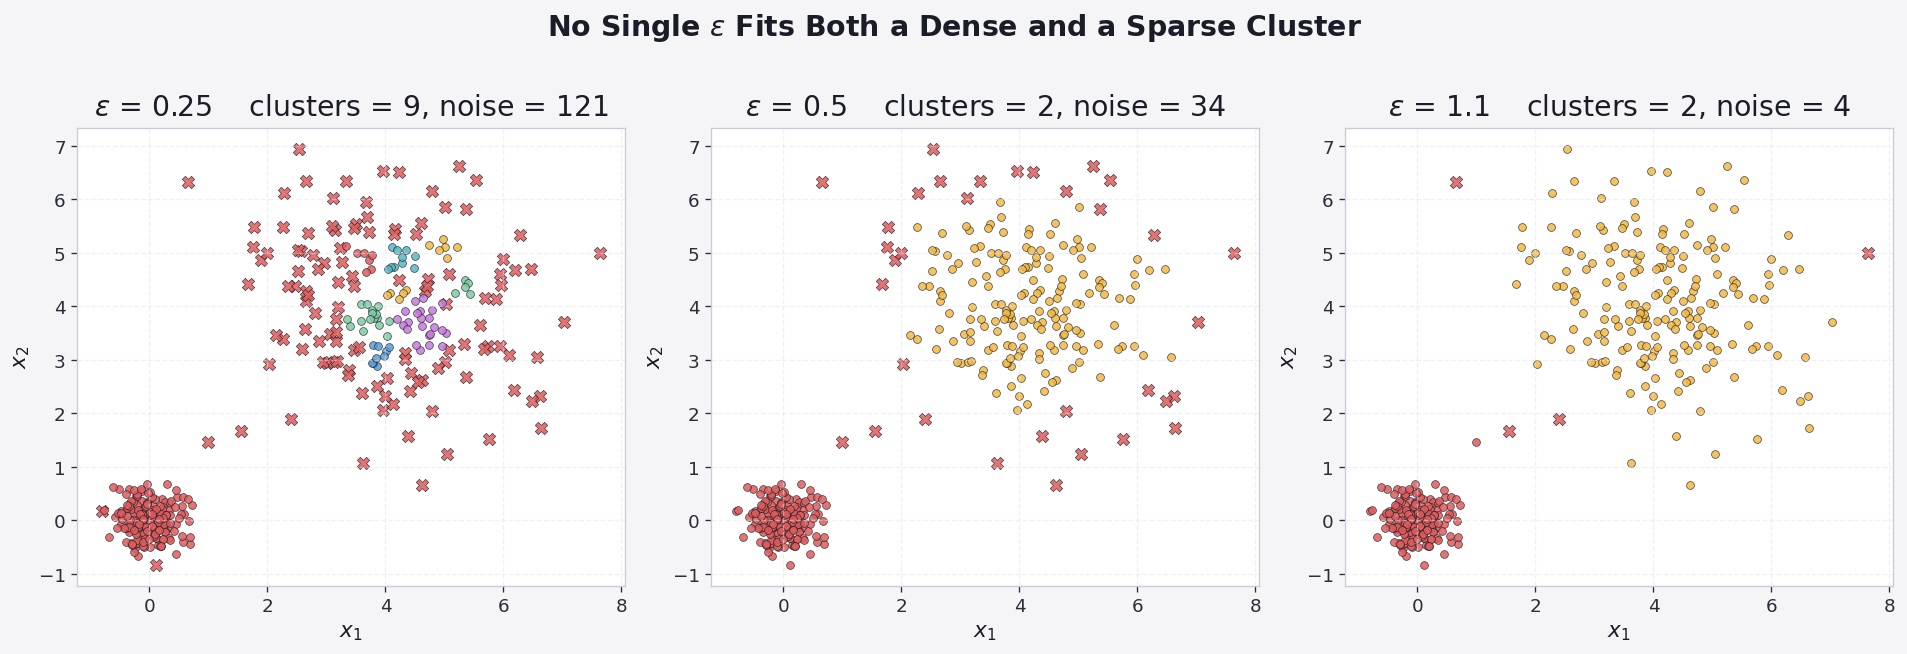

In [6]:
X_var = np.vstack([
    make_blobs(n_samples=200, centers=[(0,0)], cluster_std=0.30, random_state=0)[0],
    make_blobs(n_samples=200, centers=[(4,4)], cluster_std=1.20, random_state=1)[0],
])

fig, axes = plt.subplots(1, 3, figsize=(16, 5.3))
for ax, e in zip(axes, [0.25, 0.50, 1.10]):
    lbl = DBSCAN(eps=e, min_samples=5).fit_predict(X_var)
    uniq = sorted(set(lbl))
    for j, u in enumerate(uniq):
        m = lbl == u
        col = C1 if u == -1 else PALETTE[j%len(PALETTE)]
        marker = 'X' if u == -1 else 'o'
        size = 55 if u == -1 else 22
        ax.scatter(X_var[m,0], X_var[m,1], c=col, s=size, marker=marker,
                   edgecolors='#1a1d27', lw=0.4, alpha=0.85)
    n_clusters = len([u for u in uniq if u != -1])
    n_noise = (lbl == -1).sum()
    ax.set_title(fr'$\varepsilon$ = {e}    clusters = {n_clusters}, noise = {n_noise}', pad=8)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)
fig.suptitle('No Single $\\varepsilon$ Fits Both a Dense and a Sparse Cluster', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use DBSCAN — and when not to

| Situation | DBSCAN | K-Means | GMM | HDBSCAN |
|---|---|---|---|---|
| Arbitrary cluster shapes | ✅ | ❌ | partial | ✅ |
| Need to *find* outliers | ✅ noise label | ❌ | partial | ✅ |
| Don't know $k$ | ✅ | ❌ | ❌ | ✅ |
| Variable density clusters | ❌ single $\varepsilon$ | ❌ | partial | ✅ |

> DBSCAN is the right tool for **density-defined clusters with noise**. For variable-density data, prefer **HDBSCAN**.


---
## 🎯 Try this

1. **$k$-distance plot.** Sort the distance to the $k$-th NN for every point and plot. The "elbow" tells you a good `eps`.
2. **Vary `min_samples`.** Larger values produce noisier-looking output but more robust clusters; smaller values catch tiny but real groups. Try 3, 10, 30.
3. **Variable density.** Mix two blobs of different density and watch a single `eps` either over-merge or label the sparse cluster as noise. Switch to HDBSCAN — it handles this natively.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Core point | $\geq$ `min_samples` neighbours in $\varepsilon$-ball | Dense interior |
| Border point | Neighbour of a core but not core itself | Cluster rim |
| Noise | Neither core nor border | Cluster $-1$ |
| $\varepsilon$ | Neighbourhood radius | Kink of $k$-distance plot |
| `min_samples` | Density threshold | Often $2 \times \dim$ as a starting heuristic |
| Strength | Arbitrary shapes, automatic $k$, noise label | Great on geometric clusters |
| Weakness | Single global density | Fails on multi-density data $\to$ HDBSCAN |

**Bottom line:** DBSCAN clusters are **whatever the density says they are**. It's the right tool when shape matters more than count and you don't know $k$ in advance.